In [58]:
# Configure path.
import sys; import os
sys.path.append(os.path.abspath('..'))

%matplotlib inline
import numpy as np
import importlib, pickle
import matplotlib.pyplot as plt
plt.style.use('dissertation.mplstyle')
from IPython.display import clear_output

from python import forces, integrators, random_matrix, simulate, densities, plotters
importlib.reload(forces); importlib.reload(integrators); importlib.reload(random_matrix)
importlib.reload(simulate); importlib.reload(densities); importlib.reload(plotters);

---

#### Energy Check for MAILA

In [69]:
# Now incorporated into the simulate.py framework...
# NOTE Change track_energy to be True after meeting with Kostas
N = 50; beta = 2.0; 
M = 100; potential_name = "quadratic";
init = random_matrix.init_gue_eigenvalues(M, N)

dts = [1.0, 0.1]
total_steps_dts = [10, 10]
dt_info = []

grid = np.linspace(-2, 2, 2000)
F_exact = densities.compute_exact_cdf(N, potential_name, grid)

for j, dt in enumerate(dts):
    clear_output(wait = True)
    total_steps = total_steps_dts[j]
    print(rf"On dt {dt}. Running {total_steps} steps.")

    pipe = simulate.make_implicit_pipeline(N, dt, potential_name, beta, track_energy = False)
    trajectory = simulate.simulate_dbm(init, total_steps, pipe)

    config = {"burn_in": total_steps//4, "snapshot_interval": 1, "track_energy": False,
              "track_distance": True, "distance_type": "wasserstein", "distance_interval": 1,
              "F_exact": F_exact, "dt": dt, "grid": grid}
    
    info = simulate.analyse_trajectory(trajectory, total_steps, **config)
    dt_info.append(info)

On dt 0.1. Running 10 steps.


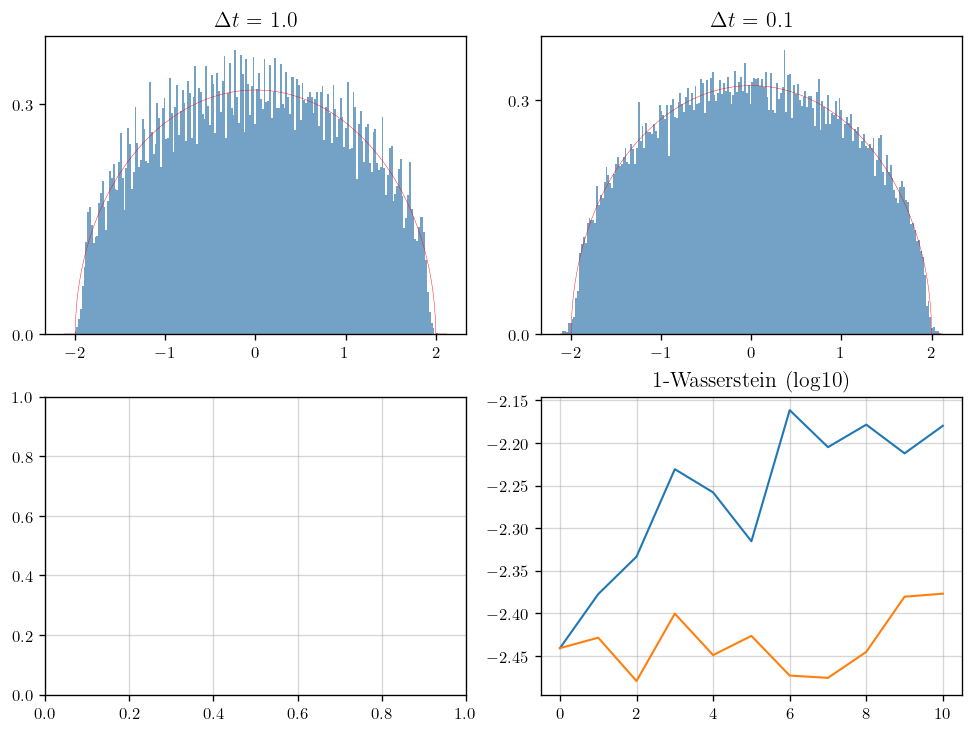

In [70]:
fig, axes_2d = plt.subplots(2, 2, figsize = (8, 6))
ax11, ax12, ax21, ax22 = axes_2d.flatten()
num_bins = 200; width = 0.25

# Snapshots, distances inside the for loop.
for j, dt in enumerate(dts):
    plotters.plot_hist(axes_2d.flatten()[j], dt_info[j]["snapshots"], potential_name = potential_name, num_bins = num_bins, width = width)
    axes_2d.flatten()[j].set_title(rf"$\Delta t$ = {dt}")

ax22.set_title(r"$1$-Wasserstein (log10)")

for j, dt in enumerate(dts):
    distances = dt_info[j]["distances"]
    ax22.plot(np.array(range(distances.shape[0])), np.log10(distances), label = dt)

plt.show()

In [ ]:
# Loop for energy information + distances.
energy_start = 0
energy_range = np.array(range(total_steps))

fig2, axes_2d_2 = plt.subplots(2, 2, figsize = (8, 6))
ax1, ax2, ax3, ax4 = axes_2d_2.flatten()

for j, dt in enumerate(dts):
    distances = dt_info[j]["distances"]
    ax22.plot(np.array(range(distances.shape[0])), np.log10(distances), label = dt)

    # Consecutive Energy Difference
    energy_diff = dt_info[j]["log_energy_y"] - dt_info[j]["log_energy_x"]
    ax1.plot(energy_range[energy_start:], np.mean(np.exp(energy_diff), axis = 1)[energy_start:], label = dt)

    transition_diff = dt_info[j]["log_transition_y_x"] - dt_info[j]["log_transition_x_y"]
    ax2.plot(energy_range[energy_start:], np.mean(np.exp(transition_diff), axis = 1)[energy_start:], label = dt)

    log_alpha_unadjusted = np.clip(np.exp(energy_diff + transition_diff), 0, 1)
    ax3.plot(energy_range, np.mean(log_alpha_unadjusted, axis = 1), label = dt) 

    det_diff = dt_info[j]["log_det_x"] - dt_info[j]["log_det_y"]
    log_alpha = np.clip(np.exp(energy_diff + det_diff + transition_diff), 0, 1)
    ax4.plot(energy_range, np.mean(log_alpha, axis = 1), label = dt)

for ax in axes_2d_2.flatten():
    ax.legend(loc = "lower right", title = r"$\Delta t$", fontsize = 13)

ax1.set_title(r"Energy Difference $H_N(y) - H_N(x)$")
ax2.set_title(r"Transition Difference $q(y, x) - q(x, y)$")
ax3.set_title("Unadjusted Acceptance Probability")
ax4.set_title("Adjusted Acceptance Probability")

plt.show()

KeyError: 'log_energy_y'

---
---
---

In [2]:
from python.newton import solve_newton_single
from numba import njit
potential_ints = {"quadratic": 0, "quad-quartic": 1, "quartic": 2, "wishart-laguerre": 3}

@njit
def temp_implicit_step(x, dt, potential_int, beta, 
                       max_newton_iters = 50, newton_tol = 1e-6, cg_tol = 1e-9):
    # ==========================================
    M, N = x.shape; next_x = np.zeros_like(x)
    noise_scale = np.sqrt(2*dt/(beta*N))
    c = 1

    newton_iters = np.zeros(M); mean_cg_iters = np.zeros(M, dtype = float); # Counters.
    coulomb = np.zeros(N); hess = np.zeros((N, N)); proposed_x = np.zeros(N) # All act as temp.
    log_energies = np.zeros(M)

    # Noise, included in the solve.
    noise = np.random.normal(0.0, 1.0, x.shape)
    z = x + noise_scale*noise 

    for m in range(M):
        current_x, trial_newton_iters, trial_avg_cg_iters = solve_newton_single(
            x[m], z[m], dt, potential_int, max_newton_iters, newton_tol, cg_tol,
            coulomb, hess, proposed_x
        )

        next_x[m] = current_x 
        newton_iters[m] = trial_newton_iters; mean_cg_iters[m] = trial_avg_cg_iters;

        # Edit: energies for this x, exp(-beta*N*H_N(x)).
        v = forces.evaluate_force(current_x, potential_int, 0, c)
        log_rep = forces.log_repulsion(current_x)
        ham = 0.5*np.sum(v) - np.sum(log_rep)
        log_energies[m] = -beta*N*ham

    return next_x, log_energies

# ==================

In [23]:
# Test: MAILA with N = 50 and dt = 1.0
N = 800; dt = 1.0; beta = 2.0; init_T = 5.0;
M = 10; potential_name = "quadratic"; potential_int = potential_ints[potential_name]

# Initialise by running unadjusted implicit trajectory, same params, init_T.
first_init = random_matrix.init_gue_eigenvalues(M, N)
init_steps = int(init_T/dt)
init_traj = np.zeros((M, N, init_steps))
init_traj[:, :, 0] = first_init

for step in range(1, init_steps):
    next_x, _ = temp_implicit_step(init_traj[:, :, step - 1], dt, potential_int, beta)
    init_traj[:, :, step] = next_x

init = init_traj[:, :, -1]

# Now run the actual trajectory.
T = 10.0;
total_steps = int(T/dt)

pipe = simulate.make_maila_pipeline(N, dt, potential_name, beta)
trajectory = simulate.simulate_dbm(init, total_steps, pipe)
config = {"burn_in": total_steps//4, "snapshot_interval": 1, "track_accepts": True}
info = simulate.analyse_trajectory(trajectory, total_steps, **config)

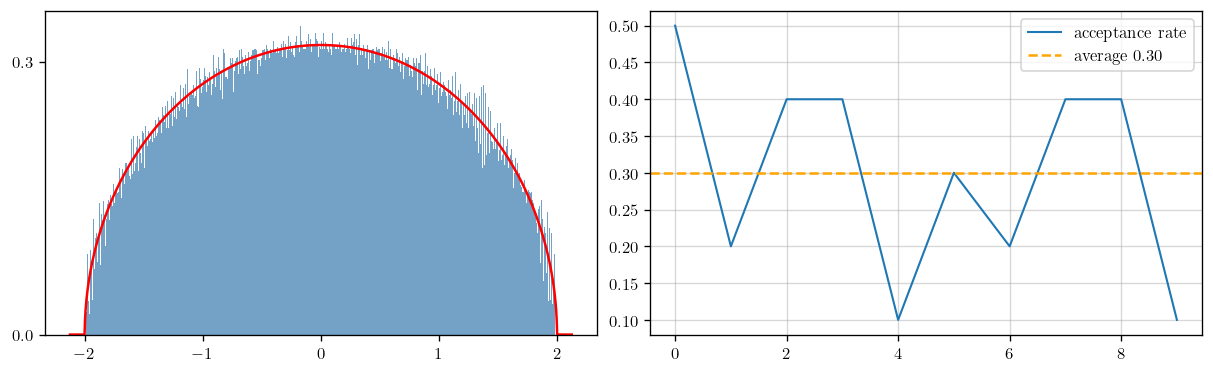

In [28]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (10, 3))
plotters.plot_hist(ax1, info["snapshots"], potential_name = potential_name, num_bins = 500)
plotters.plot_accepts(ax2, info["accepts"])
plt.show()